MODEL 1: Logistic Regression
              precision    recall  f1-score   support

  No Failure       1.00      0.97      0.98      9661
     Failure       0.53      0.91      0.67       339

    accuracy                           0.97     10000
   macro avg       0.76      0.94      0.83     10000
weighted avg       0.98      0.97      0.97     10000

Macro F1 Score : 0.8253  (target ≥ 0.85)
ROC-AUC Score  : 0.9819


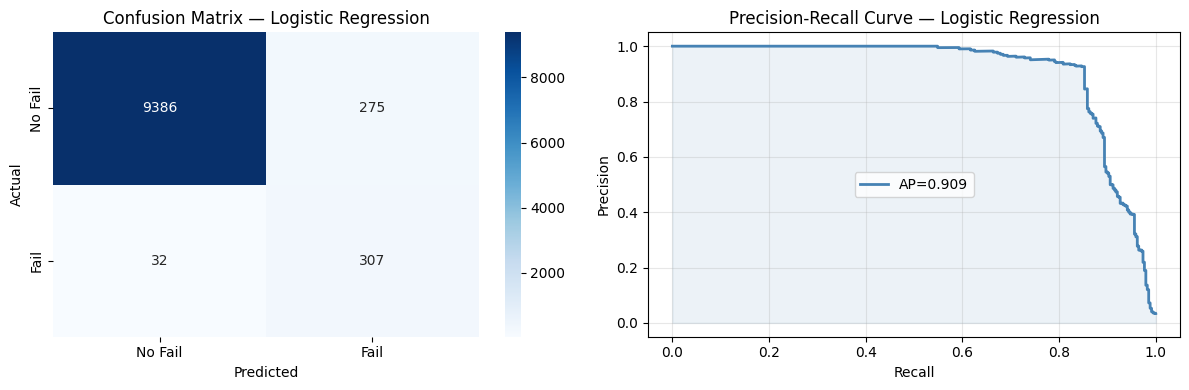


✅ Model 1 complete. Plot saved.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, roc_auc_score, precision_recall_curve,
                              average_precision_score)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
warnings.filterwarnings('ignore')

# ---- DATA & FEATURES ----
df = pd.read_csv('/kaggle/input/datasets/zenishadevani/intern/ai4i2020 (1).csv')
df.drop(columns=['UDI', 'Product ID'], inplace=True)
le = LabelEncoder()
df['Type_enc'] = le.fit_transform(df['Type'])
df.drop(columns=['Type'], inplace=True)

df['Temp_diff']     = df['Process temperature [K]'] - df['Air temperature [K]']
df['Power_W']       = df['Torque [Nm]'] * (df['Rotational speed [rpm]'] * 2 * np.pi / 60)
df['Wear_x_Torque'] = df['Tool wear [min]'] * df['Torque [Nm]']
df['Stress_proxy']  = df['Torque [Nm]'] / (df['Rotational speed [rpm]'] + 1e-6)
df['HDF_cond']      = ((df['Temp_diff'] < 8.6) & (df['Rotational speed [rpm]'] < 1380)).astype(int)
df['PWF_cond']      = ((df['Power_W'] < 3500) | (df['Power_W'] > 9000)).astype(int)
df['OSF_cond']      = (df['Wear_x_Torque'] > 11000).astype(int)

TARGET = 'Machine failure'
FAILURE_COLS = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
feature_cols = [c for c in df.columns if c not in [TARGET] + FAILURE_COLS]

X = df[feature_cols].values
y = df[TARGET].values

# ---- PIPELINE ----
pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(random_state=42, k_neighbors=5)),
    ('clf',    LogisticRegression(
                    C=0.1,
                    class_weight='balanced',
                    max_iter=1000,
                    solver='lbfgs',
                    random_state=42))
])

# ---- CROSS-VALIDATION ----
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred = cross_val_predict(pipeline, X, y, cv=cv, method='predict')
y_prob = cross_val_predict(pipeline, X, y, cv=cv, method='predict_proba')[:, 1]

print("=" * 60)
print("MODEL 1: Logistic Regression")
print("=" * 60)
print(classification_report(y, y_pred, target_names=['No Failure', 'Failure']))
macro_f1 = f1_score(y, y_pred, average='macro')
roc_auc  = roc_auc_score(y, y_prob)
print(f"Macro F1 Score : {macro_f1:.4f}  (target ≥ 0.85)")
print(f"ROC-AUC Score  : {roc_auc:.4f}")

# ---- PLOTS ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Fail', 'Fail'], yticklabels=['No Fail', 'Fail'])
axes[0].set_title('Confusion Matrix — Logistic Regression')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y, y_prob)
ap = average_precision_score(y, y_prob)
axes[1].plot(recall, precision, lw=2, color='steelblue', label=f'AP={ap:.3f}')
axes[1].fill_between(recall, precision, alpha=0.1, color='steelblue')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — Logistic Regression')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model1_logistic_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Model 1 complete. Plot saved.")